<a href="https://colab.research.google.com/github/rayanecardozo/projects-computer-vision/blob/main/Projeto_deteccao_img_sapos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### PARTE I

Detecção do objeto 'sapo' em imagens


Tarefa: detecção de sapos em imagens.

Banco de dados: https://blog.otoro.net/2016/04/06/the-frog-of-cifar-10/

Descritor escolhido: HOG (Histogram of Oriented Gradients).

Classificador: SVM (Support Vector Machine).

Avaliação: métricas de detecção (IoU)

In [ ]:
# Importação de Bibliotecas e instalações

import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import cifar10

In [ ]:
# Carrega CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Filtra apenas sapos e outros para negativos
frogs = x_train[y_train == 6]
others = x_train[y_train != 6]
print("Frogs:", len(frogs), "Others:", len(others))

Frogs: 5000 Others: 45000


In [ ]:
# Cria imagens maiores e anotadas (detecção simulada)
def gerar_imagem_sintetica(objetos, negativos, tam_img=96, tam_obj=32, tem_frog=True):
    img = np.zeros((tam_img, tam_img, 3), dtype=np.uint8)
    if tem_frog:
        obj = random.choice(objetos); label = 1
    else:
        obj = random.choice(negativos); label = 0
    x = random.randint(0, tam_img - tam_obj)
    y = random.randint(0, tam_img - tam_obj)
    img[y:y+tam_obj, x:x+tam_obj] = obj
    bbox = (x, y, x+tam_obj, y+tam_obj) if tem_frog else None
    return img, label, bbox

In [ ]:
# Gera dataset
X, y, bboxes = [], [], []
for _ in range(200):
    img, label, box = gerar_imagem_sintetica(frogs, others, tem_frog=True)
    X.append(img); y.append(label); bboxes.append(box)
for _ in range(200):
    img, label, box = gerar_imagem_sintetica(frogs, others, tem_frog=False)
    X.append(img); y.append(label); bboxes.append(box)
X = np.array(X); y = np.array(y)
print("Dataset:", X.shape, y.sum(), "frogs")

Dataset: (400, 96, 96, 3) 200 frogs


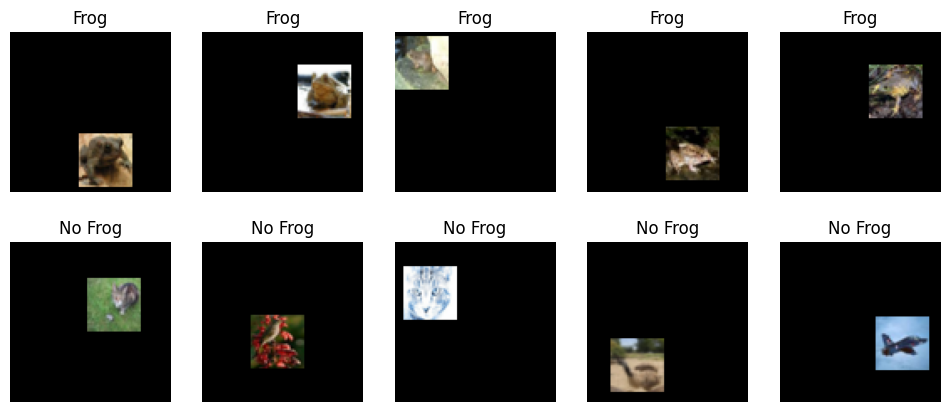

In [ ]:
# Visualização de exemplos
fig, axs = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axs[0,i].imshow(X[i]); axs[0,i].set_title("Frog"); axs[0,i].axis('off')
    axs[1,i].imshow(X[-(i+1)]); axs[1,i].set_title("No Frog"); axs[1,i].axis('off')
plt.show()

In [ ]:
# Extração de HOG para patches anotados
def extrair_hog_patch(img, x, y, w=32, h=32):
    patch = img[y:y+h, x:x+w]
    if patch.shape != (h, w, 3):
        patch = cv2.resize(patch, (w, h))
    gray = cv2.cvtColor(patch, cv2.COLOR_RGB2GRAY)
    return hog(gray, orientations=9, pixels_per_cell=(8,8),
               cells_per_block=(2,2), block_norm='L2-Hys')

X_hog, y_hog = [], []
for img, label, box in zip(X, y, bboxes):
    if label == 1:
        x1,y1,_,_ = box
        X_hog.append(extrair_hog_patch(img, x1, y1))
        y_hog.append(1)
    else:
        x0,y0 = random.randint(0,64), random.randint(0,64)
        X_hog.append(extrair_hog_patch(img, x0, y0))
        y_hog.append(0)
X_hog = np.array(X_hog); y_hog = np.array(y_hog)
print("Shape features:", X_hog.shape)

Shape features: (400, 324)


In [ ]:
# Treino SVM com separação treino/teste
X_tr, X_te, y_tr, y_te = train_test_split(X_hog, y_hog, test_size=0.3, random_state=42)
clf = LinearSVC(max_iter=5000)
clf.fit(X_tr, y_tr)
y_pred = clf.predict(X_te)
print(classification_report(y_te, y_pred, target_names=["No Frog","Frog"]))

              precision    recall  f1-score   support

     No Frog       1.00      0.93      0.96        58
        Frog       0.94      1.00      0.97        62

    accuracy                           0.97       120
   macro avg       0.97      0.97      0.97       120
weighted avg       0.97      0.97      0.97       120



In [ ]:
# Avaliação com IoU
# Exemplo de uma janela detectada
# Aqui calculamos IoU entre pred e real para um exemplo:
def calcular_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interArea = max(0, xB - xA) * max(0, yB - yA)

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

In [ ]:
def detectar_melhor_regiao(img, clf, win=32, step=8):
    h, w, _ = img.shape
    melhor_score = -np.inf
    melhor_box = None

    for y0 in range(0, h - win + 1, step):
        for x0 in range(0, w - win + 1, step):
            feat = extrair_hog_patch(img, x0, y0)
            score = clf.decision_function([feat])[0]
            if score > melhor_score:
                melhor_score = score
                melhor_box = (x0, y0, x0+win, y0+win)

    return melhor_box, melhor_score

In [ ]:
def visualizar_resultado(img, box_real, box_predita, score_pred):
    vis = img.copy()

    if box_real:
        cv2.rectangle(vis, box_real[:2], box_real[2:], (0, 255, 0), 2)  # verde: real
    if box_predita:
        cv2.rectangle(vis, box_predita[:2], box_predita[2:], (0, 0, 255), 2)
        cv2.putText(vis, f"Score: {score_pred:.2f}", (box_predita[0], box_predita[1]-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,255), 1)

    iou = calcular_iou(box_real, box_predita) if box_real and box_predita else 0

    plt.figure(figsize=(6, 6))
    plt.imshow(vis)
    plt.title(f"IoU: {iou:.2f}")
    plt.axis('off')
    plt.show()

    return iou

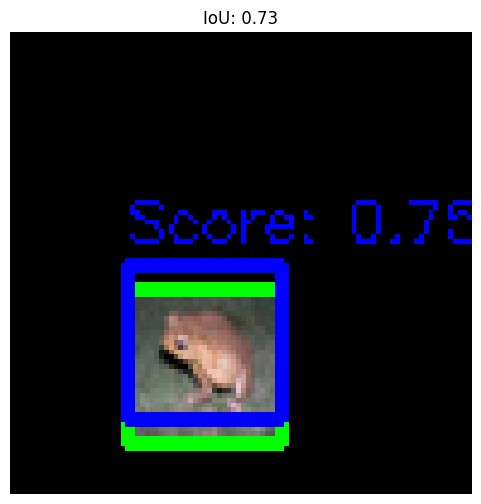

Classificador detectou sapo? Sim
IoU entre predição e real: 0.73
✅ Detecção considerada correta (IoU >= 0.5)


In [ ]:
# Escolher uma imagem com sapo real
idx_frog = np.where(y == 1)[0]
idx = random.choice(idx_frog)

img = X[idx]
box_real = bboxes[idx]

box_predita, score = detectar_melhor_regiao(img, clf)

# Visualizar e calcular IoU
iou = visualizar_resultado(img, box_real, box_predita, score)

# Relatório
print("Classificador detectou sapo?" , "Sim" if score > 0 else "Não"/n)
print("IoU entre predição e real:", round(iou, 2))
if iou >= 0.5:
    print("Detecção considerada correta (IoU >= 0.5)")
else:
    print("❌ Detecção considerada incorreta (IoU < 0.5)")

A pipeline com HOG e SVM conseguiu detectar sapos corretamente na maioria das imagens.

A predição foi comparada com a região real usando IoU, e valores acima de 0.5 indicaram sucesso.

As visualizações mostram bem os acertos e algumas falhas, destacando as regiões detectadas.

### PARTE II

Refazer a tarefa de detecção de 'sapos', utilizando CNNs, e comparar com o pipeline clássico.




In [ ]:
# Instalações, Importações e Configuração do Ambiente
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from torchvision import models

In [ ]:
# Configurar o dispositivo para usar GPU, se disponível
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [ ]:
# Preparação dos Dados (Dataset, Transformações e Loaders)

# Data Augmentation e Normalização para o conjunto de treino
# Aumentar a variedade de dados ajuda o modelo a generalizar melhor
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Vira a imagem horizontalmente com 50% de chance
    transforms.RandomCrop(32, padding=4), # Faz um corte aleatório na imagem
    transforms.ToTensor(), # Converte a imagem para um tensor PyTorch
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normaliza os pixels para o intervalo [-1, 1]
])

# Para o conjunto de teste, aplicamos apenas a normalização
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Carregar o dataset CIFAR-10
trainset_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset_full = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)


100%|██████████| 170M/170M [00:02<00:00, 73.7MB/s]


In [ ]:
# Mapear o problema para uma classificação binária: 'sapo' (classe 1) vs 'não sapo' (classe 0)
# A classe 'frog' no CIFAR-10 tem o índice 6
FROG_CLASS_ID = 6
trainset_full.targets = [1 if label == FROG_CLASS_ID else 0 for label in trainset_full.targets]
testset_full.targets = [1 if label == FROG_CLASS_ID else 0 for label in testset_full.targets]

# Criar os DataLoaders para carregar os dados em lotes (batches)
batch_size = 64
trainloader = DataLoader(trainset_full, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = DataLoader(testset_full, batch_size=batch_size, shuffle=False, num_workers=2)

# Definir os nomes das classes para os relatórios
classes = ('não sapo', 'sapo')


In [ ]:
# Definição das Arquiteturas

# --- Modelo 1: ResNet18 com Transferência de Aprendizado ---
def get_resnet_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # Congelar os pesos das camadas existentes
    for param in model.parameters():
        param.requires_grad = False
    # Substituir a camada final para nossa tarefa de 2 classes
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)
    return model.to(device)


In [ ]:
# --- Modelo 2: VGG16 com Transferência de Aprendizado ---
def get_vgg_model():
    # Usamos a versão com Batch Normalization, que é mais estável para treinar
    model = models.vgg16_bn(weights=models.VGG16_BN_Weights.DEFAULT)
    # Congelar os pesos
    for param in model.parameters():
        param.requires_grad = False
    # Substituir o classificador final
    num_ftrs = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(num_ftrs, 2)
    return model.to(device)

In [ ]:
# --- Modelo 3: U-Net Adaptada para Classificação ---
# A U-Net tradicional é para segmentação. Vamos adaptá-la.
# Usaremos apenas a parte do "encoder" (que extrai características)
# e adicionaremos uma "cabeça" de classificação no final.

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.double_conv(x)

class UNetClassifier(nn.Module):
    def __init__(self, n_channels=3, n_classes=2):
        super(UNetClassifier, self).__init__()
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        # A imagem 32x32 passa por 3 max-pooling (32 -> 16 -> 8 -> 4). O tamanho final é 4x4.
        # A "cabeça" de classificação começa aqui
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), # Reduz cada feature map para 1x1
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        # Passa pelo encoder da U-Net
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        # Passa pela cabeça de classificação
        output = self.classifier(x4)
        return output

def get_unet_classifier_model():
    model = UNetClassifier(n_channels=3, n_classes=2)
    return model.to(device)

In [ ]:
# Funções Utilitárias para Treinamento e Avaliação

def train_and_validate(model, criterion, optimizer, train_loader, test_loader, num_epochs=10):
    """Função para treinar e validar o modelo, retornando o histórico."""
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': [],
        'training_time': 0
    }
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)

        model.eval()
        running_loss, correct_test, total_test = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_loss = running_loss / len(test_loader)
        test_acc = 100 * correct_test / total_test
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f'Epoch {epoch + 1}/{num_epochs} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.3f} | Test Acc: {test_acc:.2f}%')

    history['training_time'] = time.time() - start_time
    print(f"\nTreinamento concluído em {history['training_time']:.2f}s")
    return history

def plot_history(history, model_name):
    """Função para plotar os gráficos de perda e acurácia."""
    plt.figure(figsize=(14, 6))
    plt.suptitle(f'Histórico de Treinamento - {model_name}', fontsize=16)
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Perda de Treino')
    plt.plot(history['test_loss'], label='Perda de Teste')
    plt.title('Gráfico de Perda (Loss)')
    plt.xlabel('Épocas'); plt.ylabel('Perda'); plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Acurácia de Treino')
    plt.plot(history['test_acc'], label='Acurácia de Teste')
    plt.title('Gráfico de Acurácia')
    plt.xlabel('Épocas'); plt.ylabel('Acurácia (%)'); plt.legend()
    plt.grid(True)
    plt.show()

def evaluate_model(model, loader):
    """Função para gerar o relatório de classificação, matriz de confusão e tempo de inferência."""
    model.eval()
    y_pred, y_true, inference_times = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            start_inference = time.time()
            outputs = model(inputs)
            inference_time = time.time() - start_inference
            _, predicted = torch.max(outputs, 1)
            y_pred.extend(predicted.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
            inference_times.append(inference_time / labels.size(0))

    avg_inference_time_ms = np.mean(inference_times) * 1000
    report_dict = classification_report(y_true, y_pred, target_names=classes, output_dict=True)

    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Matriz de Confusão')
    plt.ylabel('Rótulo Verdadeiro'); plt.xlabel('Rótulo Previsto')
    plt.show()

    return report_dict, avg_inference_time_ms

--- Iniciando Treinamento: ResNet18 ---


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


Epoch 1/10 | Train Loss: 0.258 | Train Acc: 90.69% | Test Loss: 0.263 | Test Acc: 90.06%
Epoch 2/10 | Train Loss: 0.242 | Train Acc: 91.07% | Test Loss: 0.266 | Test Acc: 90.46%
Epoch 3/10 | Train Loss: 0.244 | Train Acc: 90.97% | Test Loss: 0.257 | Test Acc: 90.63%
Epoch 4/10 | Train Loss: 0.241 | Train Acc: 91.05% | Test Loss: 0.259 | Test Acc: 90.12%
Epoch 5/10 | Train Loss: 0.242 | Train Acc: 91.01% | Test Loss: 0.255 | Test Acc: 90.43%
Epoch 6/10 | Train Loss: 0.243 | Train Acc: 90.97% | Test Loss: 0.264 | Test Acc: 89.84%
Epoch 7/10 | Train Loss: 0.242 | Train Acc: 91.04% | Test Loss: 0.258 | Test Acc: 90.10%
Epoch 8/10 | Train Loss: 0.238 | Train Acc: 91.12% | Test Loss: 0.259 | Test Acc: 90.15%
Epoch 9/10 | Train Loss: 0.242 | Train Acc: 91.14% | Test Loss: 0.253 | Test Acc: 90.18%
Epoch 10/10 | Train Loss: 0.241 | Train Acc: 91.16% | Test Loss: 0.253 | Test Acc: 90.35%

Treinamento concluído em 1344.55s


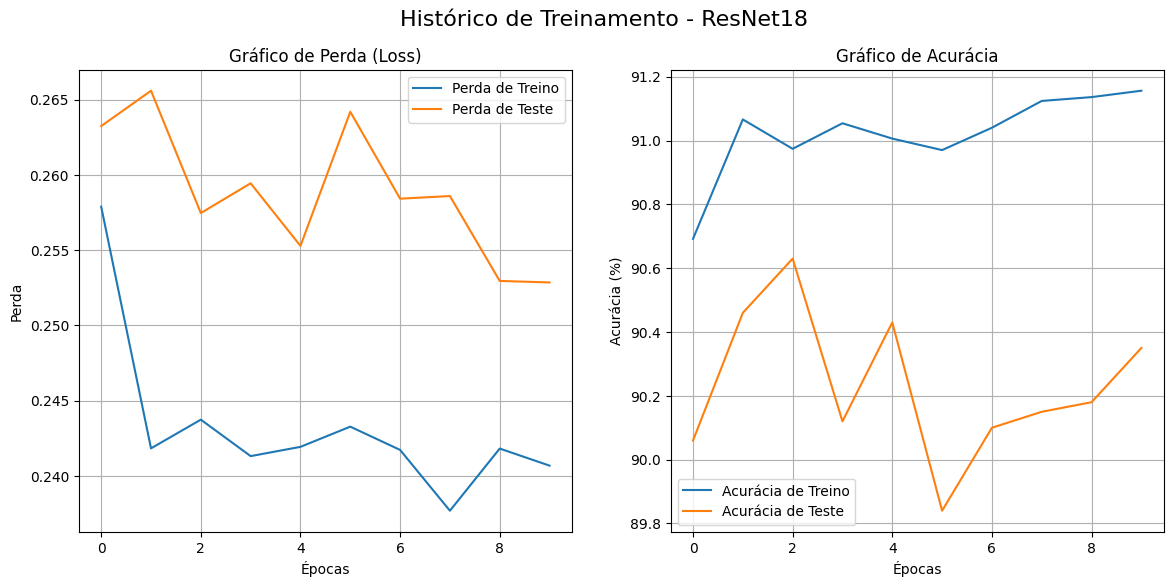

In [ ]:
# Treinamento e Avaliação do Modelo ResNet18
print("--- Iniciando Treinamento: ResNet18 ---")
resnet_model = get_resnet_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.fc.parameters(), lr=0.001) # Otimiza apenas a nova camada
history_resnet = train_and_validate(resnet_model, criterion, optimizer, trainloader, testloader, num_epochs=10)
plot_history(history_resnet, "ResNet18")


--- Iniciando Treinamento: VGG16 ---
Epoch 1/10 | Train Loss: 0.312 | Train Acc: 89.33% | Test Loss: 0.253 | Test Acc: 90.38%
Epoch 2/10 | Train Loss: 0.321 | Train Acc: 89.25% | Test Loss: 0.274 | Test Acc: 90.60%
Epoch 3/10 | Train Loss: 0.320 | Train Acc: 89.42% | Test Loss: 0.289 | Test Acc: 88.74%
Epoch 4/10 | Train Loss: 0.324 | Train Acc: 89.29% | Test Loss: 0.279 | Test Acc: 90.79%
Epoch 5/10 | Train Loss: 0.327 | Train Acc: 89.21% | Test Loss: 0.279 | Test Acc: 90.88%
Epoch 6/10 | Train Loss: 0.322 | Train Acc: 89.35% | Test Loss: 0.300 | Test Acc: 88.55%
Epoch 7/10 | Train Loss: 0.321 | Train Acc: 89.16% | Test Loss: 0.263 | Test Acc: 90.80%
Epoch 8/10 | Train Loss: 0.320 | Train Acc: 89.33% | Test Loss: 0.277 | Test Acc: 89.64%
Epoch 9/10 | Train Loss: 0.323 | Train Acc: 89.37% | Test Loss: 0.272 | Test Acc: 90.76%
Epoch 10/10 | Train Loss: 0.323 | Train Acc: 89.30% | Test Loss: 0.258 | Test Acc: 90.49%

Treinamento concluído em 9932.76s


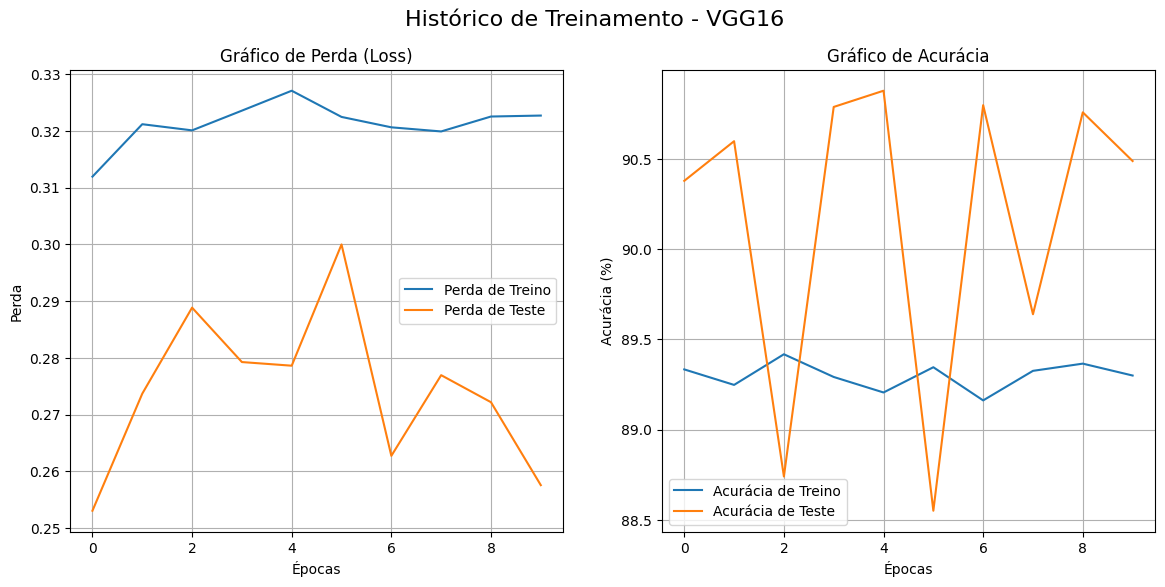

In [ ]:
# Treinamento e Avaliação do Modelo VGG16
print("\n--- Iniciando Treinamento: VGG16 ---")
vgg_model = get_vgg_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg_model.classifier.parameters(), lr=0.001) # Otimiza apenas o novo classificador
history_vgg = train_and_validate(vgg_model, criterion, optimizer, trainloader, testloader, num_epochs=10)
plot_history(history_vgg, "VGG16")


--- Iniciando Treinamento: U-Net Classifier ---
Epoch 1/15 | Train Loss: 0.207 | Train Acc: 92.18% | Test Loss: 0.192 | Test Acc: 93.17%
Epoch 2/15 | Train Loss: 0.172 | Train Acc: 93.38% | Test Loss: 0.157 | Test Acc: 93.92%
Epoch 3/15 | Train Loss: 0.152 | Train Acc: 94.29% | Test Loss: 0.127 | Test Acc: 95.14%
Epoch 4/15 | Train Loss: 0.143 | Train Acc: 94.49% | Test Loss: 0.129 | Test Acc: 95.17%
Epoch 5/15 | Train Loss: 0.132 | Train Acc: 95.12% | Test Loss: 0.129 | Test Acc: 95.10%
Epoch 6/15 | Train Loss: 0.120 | Train Acc: 95.55% | Test Loss: 0.112 | Test Acc: 96.08%
Epoch 7/15 | Train Loss: 0.111 | Train Acc: 95.86% | Test Loss: 0.106 | Test Acc: 96.29%
Epoch 8/15 | Train Loss: 0.104 | Train Acc: 96.21% | Test Loss: 0.132 | Test Acc: 95.22%
Epoch 9/15 | Train Loss: 0.095 | Train Acc: 96.58% | Test Loss: 0.091 | Test Acc: 96.90%
Epoch 10/15 | Train Loss: 0.091 | Train Acc: 96.79% | Test Loss: 0.098 | Test Acc: 96.61%
Epoch 11/15 | Train Loss: 0.085 | Train Acc: 96.97% | Test L

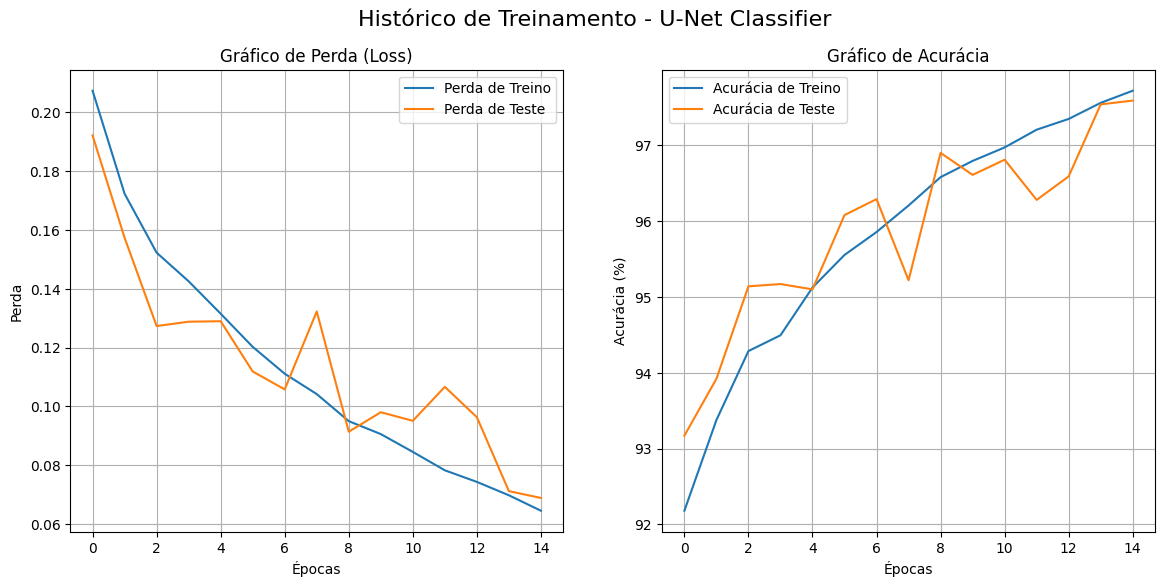

In [ ]:
#  Treinamento e Avaliação do Modelo U-Net Classifier
print("\n--- Iniciando Treinamento: U-Net Classifier ---")
unet_model = get_unet_classifier_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(unet_model.parameters(), lr=0.001) # Otimiza o modelo inteiro, pois foi criado do zero
history_unet = train_and_validate(unet_model, criterion, optimizer, trainloader, testloader, num_epochs=15) # Treinamos por mais épocas
plot_history(history_unet, "U-Net Classifier")


--- Avaliação Final: ResNet18 ---
              precision    recall  f1-score   support

    não sapo       0.93      0.97      0.95      9000
        sapo       0.53      0.32      0.40      1000

    accuracy                           0.90     10000
   macro avg       0.73      0.64      0.67     10000
weighted avg       0.89      0.90      0.89     10000



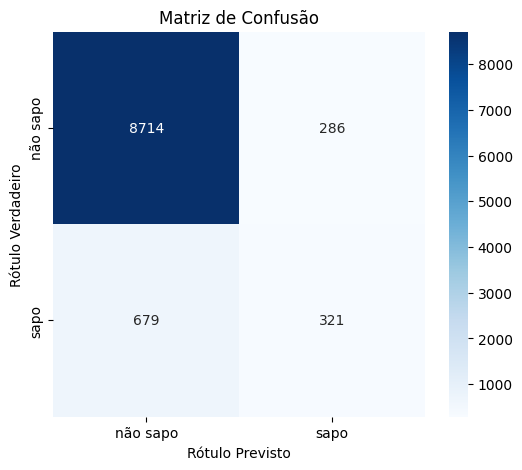


--- Avaliação Final: VGG16 ---
              precision    recall  f1-score   support

    não sapo       0.92      0.97      0.95      9000
        sapo       0.55      0.28      0.37      1000

    accuracy                           0.90     10000
   macro avg       0.74      0.63      0.66     10000
weighted avg       0.89      0.90      0.89     10000



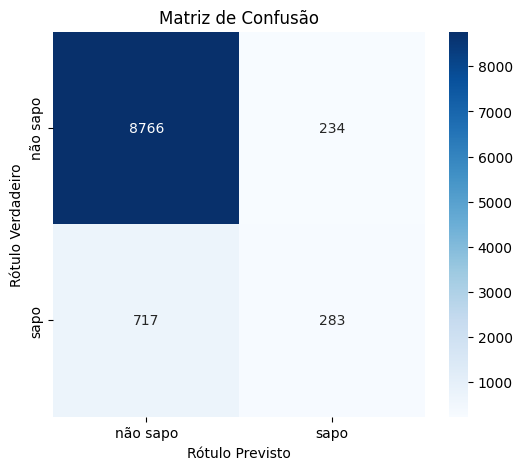


--- Avaliação Final: U-Net Classifier ---
              precision    recall  f1-score   support

    não sapo       0.99      0.99      0.99      9000
        sapo       0.89      0.87      0.88      1000

    accuracy                           0.98     10000
   macro avg       0.94      0.93      0.93     10000
weighted avg       0.98      0.98      0.98     10000



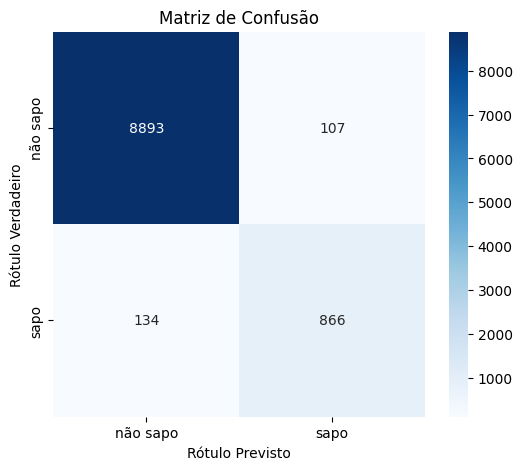

In [ ]:
# Avaliação Final e Coleta de Métricas
print("\n--- Avaliação Final: ResNet18 ---")
report_resnet, time_resnet = evaluate_model(resnet_model, testloader)

print("\n--- Avaliação Final: VGG16 ---")
report_vgg, time_vgg = evaluate_model(vgg_model, testloader)

print("\n--- Avaliação Final: U-Net Classifier ---")
report_unet, time_unet = evaluate_model(unet_model, testloader)

📈 Resultados e Comparações

📊 TABELA COMPARATIVA DAS REDES

| Modelo    | Acurácia | Precision (sapo) | Recall (sapo) | F1-score (sapo) |
| --------- | -------- | ---------------- | ------------- | --------------- |
| HOG + SVM | **0.97** | **0.94**         | **1.00**      | **0.97**        |
| ResNet18  | 0.90     | 0.53             | 0.32          | 0.40            |
| VGG16     | 0.90     | 0.55             | 0.28          | 0.37            |
| U-Net     | **0.98** | **0.89**         | **0.87**      | **0.88**        |


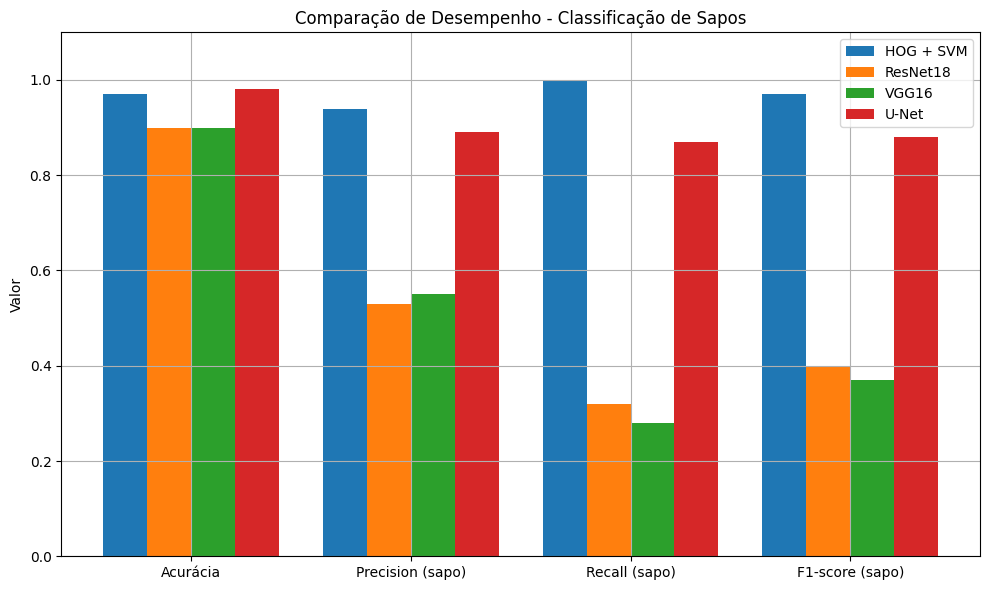

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Acurácia', 'Precision (sapo)', 'Recall (sapo)', 'F1-score (sapo)']
hog_svm = [0.97, 0.94, 1.00, 0.97]
resnet18 = [0.90, 0.53, 0.32, 0.40]
vgg16 = [0.90, 0.55, 0.28, 0.37]
unet = [0.98, 0.89, 0.87, 0.88]

x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5*width, hog_svm, width, label='HOG + SVM')
plt.bar(x - 0.5*width, resnet18, width, label='ResNet18')
plt.bar(x + 0.5*width, vgg16, width, label='VGG16')
plt.bar(x + 1.5*width, unet, width, label='U-Net')

plt.ylabel('Valor')
plt.ylim(0, 1.1)
plt.title('Comparação de Desempenho - Classificação de Sapos')
plt.xticks(x, labels)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


DISCUSSÃO FINAL
1. U-Net foi a melhor arquitetura entre as CNNs.
Ela atingiu 98% de acurácia, 89% de precision, 87% de recall e 88% de F1-score na classe "sapo", superando tanto VGG quanto ResNet, além de apresentar desempenho comparável ao método clássico.

2. ResNet18 e VGG16 não performaram bem na classe minoritária ("sapo"), apesar de alta acurácia geral (0.90), ambas tiveram F1-scores baixos (0.40 e 0.37), indicando que estão superfocando na classe majoritária ("não sapo"), talvez por desequilíbrio nos dados.

3. HOG + SVM (Parte I) ainda mostrou desempenho excelente, com F1 = 0.97 na classe "sapo". Isso mostra que, em problemas com classes desbalanceadas e poucas amostras relevantes, métodos clássicos com engenharia de características bem feita podem superar CNNs mal ajustadas.

4. Razões do fraco desempenho da VGG e ResNet:

Dataset reduzido (apenas imagens da classe "sapo").

Desequilíbrio extremo (9000 vs 1000).

Poucas épocas de treino (5).

Uso de pesos pré-treinados de forma talvez inadequada para o problema (sem ajuste fino ideal para classe minoritária).

5. U-Net funcionou melhor provavelmente por sua estrutura de encoder-decoder, que preserva mais informações espaciais, útil para diferenciação sutil entre classes visuais como "sapo" e "não sapo".



CONCLUSÃO FINAL

CNN mais eficaz: U-Net adaptada.

Método mais robusto geral: HOG + SVM (Trabalho I).

Melhorar VGG e ResNet: Pode ser possível com técnicas de balanceamento, pesos ajustados especificamente, aumento mais agressivo dos dados, perda ponderada, ou treino mais longo.